# Стохастические дифференциальные уравнения

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
%matplotlib inline

## Численные методы

Мы будем рассматривать одномерные и многомерные уравнения типа

$$
dX_t = \mu(t, X_t) dt   + \sigma(t,X_t) dW_t
$$

в смысле Ито. Со своими особенностями численные методы транслируются из области обыкновенных дифференциальных уравнений. Прежде всего, есть очень дешёвый метод, аналогичный явному методу Эйлера, который называется методом Эйлера-Маруямы. Решение вычисляется последовательно в дискретных точках $t_k$, где $X_{t_0}=x_0$ берётся из начального условия:

$$
X_{t_{k+1}} = b(t_k,X_{t_k}) \Delta t_{k} + \sigma(t_k,X_{t_k}) \Delta W_{k}.
$$

Поскольку мы имеем дело со случайными процессами, можно по-разному анализировать сходимость данного метода, одна из возможных метрик -- матожидание модуля максимальной ошибки.

In [ ]:
class SDESolver:
    
    def __init__(self, b, sigma):
        self.b = b 
        self.sigma = sigma
    
    def step(self, x, t, tnext):
        """One integration step

        Raises:
            NotImplementedError: if not implemented
        """        
        raise NotImplementedError
    
    def solve(self, x0, ts):
        """Computes the solution on the given grid ts with x0 as initial condition

        Args:
            x0 float[]: initial condition (N,d,) or (d,)
            ts float[]: time grid (T,)
        Returns:
            xs float[]: approximated solution (N,d,T) at points ts
        """
        try:
            if(len(x0.shape)==1):
                x0 = x0[None, :]
        except:
            #a number?
            x0 = np.ones([1,1])*x0
                    
        xs = np.zeros([x0.shape[0], x0.shape[1], len(ts)])
        xs[...,0] = x0
        
        for i in np.arange(1,len(ts)):
            xs[...,i] = self.step(xs[...,i-1],ts[i-1],ts[i])
        
        return xs
    
class EulerSolver(SDESolver):
    
    def __init__(self,b,sigma):
        super(EulerSolver, self).__init__(b,sigma)
       
        
    def step(self, x, t, tnext):
        """Makes Euler step

        Args:
            x float[]: previous point (N,d)
            t float: previous time
            tnext float: next time
        """            
        dt = tnext - t
        # Шум той же формы, что состояние x
        dW = np.sqrt(dt) * np.random.standard_normal(size=x.shape)
        
        b_val = self.b(t, x)
        sigma_val = self.sigma(t, x)
        
        # Универсальная обработка: если sigma вектор - поэлементно, если матрица - через sum
        if sigma_val.ndim == x.ndim:
            stoch_part = sigma_val * dW
        else:
            # Для случая (N, d, d) * (N, 1, d) -> sum по последней оси
            stoch_part = np.sum(sigma_val * dW[:, None, :], axis=-1)
            
        return x + b_val * dt + stoch_part
        
        

Не забудем про библиотеку процессов, чтобы было с чем сопоставить. 

In [15]:
class WienerDriftProcess:
    
    def __init__(self, gamma=0, sigma=1):
        self.gamma = gamma
        self.sigma = sigma
        
    def sampleTrajs(self,x0,ts):
        '''
        Simulates trajectories of Wiener process
        Input
        float x0 -- initial value  (N,d)
        float[] ts -- times
        Returns
        float[] of shape (Ntraj,xs.shape[0],len(ts))
        '''
        xs=np.zeros(list(x0.shape)+list(ts.shape))
        xs[...,0]=x0
        for kk in np.arange(1,len(ts)):
            noises=np.random.standard_normal(size=x0.shape)
            xs[...,kk]=xs[...,kk-1] + self.sigma*np.sqrt(ts[kk]-ts[kk-1])*noises
    
        return xs + self.gamma*ts[None,:]
    
class GBMModel:
    
    def __init__(self, mu, sigma):
        self.mu = mu
        self.sigma = sigma
        self.wien = WienerDriftProcess()
        
    def sampleTrajs(self,x0,ts):
        '''
        Simulates trajectories of GBM with parameters mu and sigma
        Input
        float[] x0 -- initial price, (N,d,)
        float[] ts -- times
        Returns
        float[] of shape (Ntraj,d,len(ts)) , trajectories
        '''
        wienProcs = self.wien.sampleTrajs(np.zeros_like(x0),ts)
        if(wienProcs.shape[1]>1):
                xs = x0[...,None] * np.exp((self.mu[...,None] - self.sigma[...,None]**2/2)*(ts-ts[0]) + self.sigma[...,None]*wienProcs)
        else:
                xs = x0[...,None] * np.exp((self.mu - self.sigma**2/2)*(ts-ts[0]) + self.sigma*wienProcs)
        return xs
        

In [16]:
a=0
b=1
Nt=20
h=(b-a)/Nt
ts = np.arange(a,b+h/2,h)

mu=np.array([0.05])
sigma=np.array([0.2])

Ntrajs=3
x0=np.array([100])[None,:]*np.ones([Ntrajs,1])

gbm = GBMModel(mu,sigma)

#set the seed
np.random.seed(100500)
trajs = gbm.sampleTrajs(x0,ts)
print(trajs.shape)

(3, 1, 21)


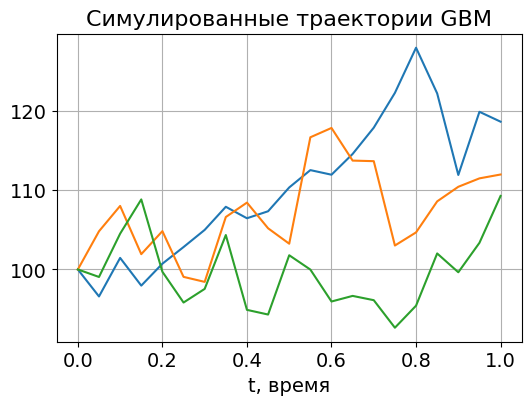

In [17]:
#plots

f, ax1 = plt.subplots(figsize=(6,4))

ax1.grid()
ax1.set_title('Симулированные траектории GBM',fontsize=16)
ax1.set_xlabel('t, время',fontsize=14)
ax1.tick_params(axis='x', labelsize=14)
ax1.tick_params(axis='y', labelsize=14)
ax1.plot(ts,trajs[:,0,:].T)

In [18]:
#set the seed
np.random.seed(100500)


def bGBM(t,x):
    return mu*x
def sigmaGBM(t,x):
    return sigma*x

solver = EulerSolver(bGBM,sigmaGBM)

apprTrajs = solver.solve(x0,ts)
print(apprTrajs.shape)

(3, 1, 21)


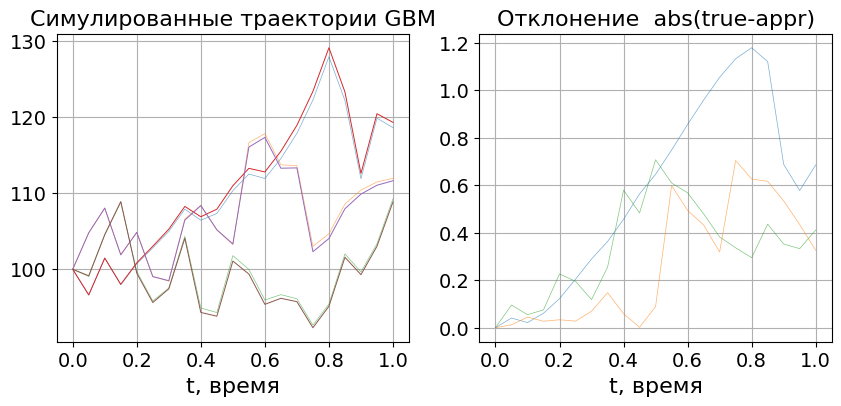

In [19]:
#plots

f, (ax1, ax2) = plt.subplots(1,2,figsize=(10,4))

ax1.grid()
ax1.set_title('Симулированные траектории GBM',fontsize=16)
ax1.set_xlabel('t, время',fontsize=16)
ax1.tick_params(axis='x', labelsize=14)
ax1.tick_params(axis='y', labelsize=14)
ax1.plot(ts,trajs[:,0,:].T,alpha=0.6,linewidth=0.5)
plt.gca().set_prop_cycle(None)
ax1.plot(ts,apprTrajs[:,0,:].T,linewidth=0.7)


ax2.grid()
ax2.set_title('Отклонение  abs(true-appr)',fontsize=16)
ax2.set_xlabel('t, время',fontsize=16)
ax2.tick_params(axis='x', labelsize=14)
ax2.tick_params(axis='y', labelsize=14)
ax2.plot(ts,np.abs(trajs[:,0,:].T-apprTrajs[:,0,:].T),alpha=0.6,linewidth=0.5)

## Процесс Орнштейна-Уленбека

Рассмотрим вариант процесса с возвратом к заданному среднему $\mu$. Мы ранее выражали этот процесс через интеграл Римана от Винеровского  процесса, а ещё как гауссовский процесс путём подсчёта его ковариационной функции.

$$
dX_t = \theta (\mu-X_t) dt + \sigma dW_t.
$$

Решим это уравнение численно с помощью изученного метода и проверим, есть ли эффект возврата к среднему.

In [22]:
a=0
b=1000
Nt=10000
h=(b-a)/Nt
ts = np.arange(a,b+h/2,h)

mu=0.15 # стационарная ставка?
theta = 0.025 # скорость стремления
sigma =0.02 #волатильность ставки

def bOU(t,x):
    return theta*(mu-x)
def sigmaOU(t,x):
    return sigma*np.ones_like(x)

solver = EulerSolver(bOU,sigmaOU)

Ntrajs=3
x0=np.array([0.95])[None,:]*np.ones([Ntrajs,1])


apprTrajs = solver.solve(x0,ts)
print(apprTrajs.shape)

(3, 1, 10001)


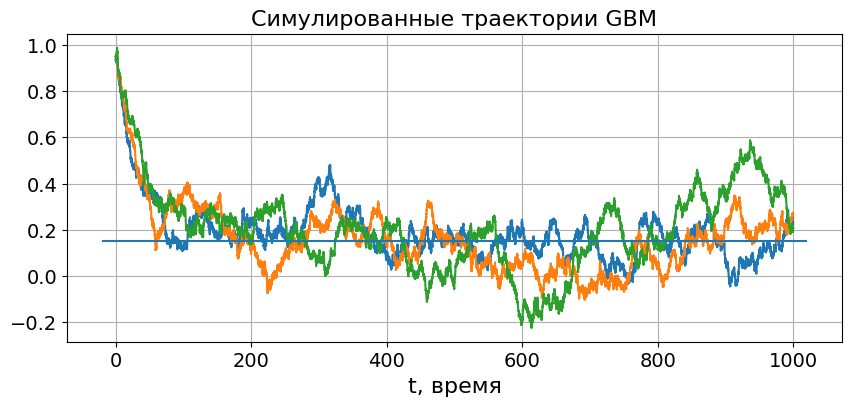

In [23]:
#plots
offset=20
f, ax1 = plt.subplots(figsize=(10,4))

ax1.grid()
ax1.set_title('Симулированные траектории GBM',fontsize=16)
ax1.set_xlabel('t, время',fontsize=16)
ax1.tick_params(axis='x', labelsize=14)
ax1.tick_params(axis='y', labelsize=14)
ax1.plot(ts,apprTrajs[:,0,:].T)
ax1.hlines(mu, a-offset, b+offset, colors=None, linestyles='solid')

# Модели процентных ставок

### Модель Халла-Уайта

# Модель Халла-Уайта (Hull-White One-Factor Model)

## 1. Определение модели

Модель Халла-Уайта — это однофакторная модель краткосрочной процентной ставки $r_t$, представляющая собой обобщение модели Васичека. Она описывается следующим стохастическим дифференциальным уравнением (СДУ):

$$ dr_t = (\theta(t) - a r_t)dt + \sigma dW_t $$

где:
*   $r_t$ — мгновенная безрисковая процентная ставка в момент времени $t$.
*   $a > 0$ — параметр скорости возврата к среднему (mean reversion speed). Определяет, насколько быстро ставка стремится к своему долгосрочному уровню.
*   $\sigma > 0$ — волатильность краткосрочной ставки.
*   $W_t$ — стандартный винеровский процесс (броуновское движение).
*   $\theta(t)$ — детерминированная функция времени, обеспечивающая точное соответствие модели текущей рыночной временной структуре процентных ставок.

## 2. Ключевые свойства

1.  **Гауссовость**: Поскольку коэффициенты линейны по $r_t$, а шум аддитивен, распределение $r_t$ остается нормальным. Это позволяет получать аналитические формулы для цен облигаций и опционов на облигации.
2.  **Отрицательные ставки**: Как и модель Васичека, Hull-White допускает отрицательные значения процентных ставок с ненулевой вероятностью. Это делает её менее применимой в средах с высокими ставками, но удобной для калибровки в низкопроцентных средах.
3.  **Калибровка**: Главное преимущество перед Васичеком — наличие функции $\theta(t)$. Подбирая $\theta(t)$, можно точно воспроизвести цены всех рыночных бескупонных облигаций (zero-coupon bonds) на начальный момент времени $t=0$.

## 3. Численная реализация

Для генерации траекторий используется метод Эйлера-Маруямы. Дискретная схема на шаге $\Delta t$:

$$ r_{t+\Delta t} = r_t + (\theta(t) - a r_t)\Delta t + \sigma \sqrt{\Delta t} Z_t, \quad Z_t \sim N(0,1) $$

---

В полной версии модели функция $\theta(t)$ калибруется так, чтобы точно воспроизводить начальную рыночную кривую доходности $P(0, T)$. Рассмотрим упрощенный сценарий для демонстрации влияния структуры дрейфа:

1. **Халл-Уайт с трендом**
    *   Здесь функция $\theta(t)$ линейно растет во времени.
    *   Равновесный уровень ставки смещается вверх: $r_{eq}(t) \approx r^* + \frac{c}{a}t$.
    *   Имитирует ситуацию, когда рынок ожидает **постепенного повышения ставок** (восходящая кривая доходности или макроэкономический тренд).

C:\Users\XuMuKPad\AppData\Local\Temp\ipykernel_14360\1222658974.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


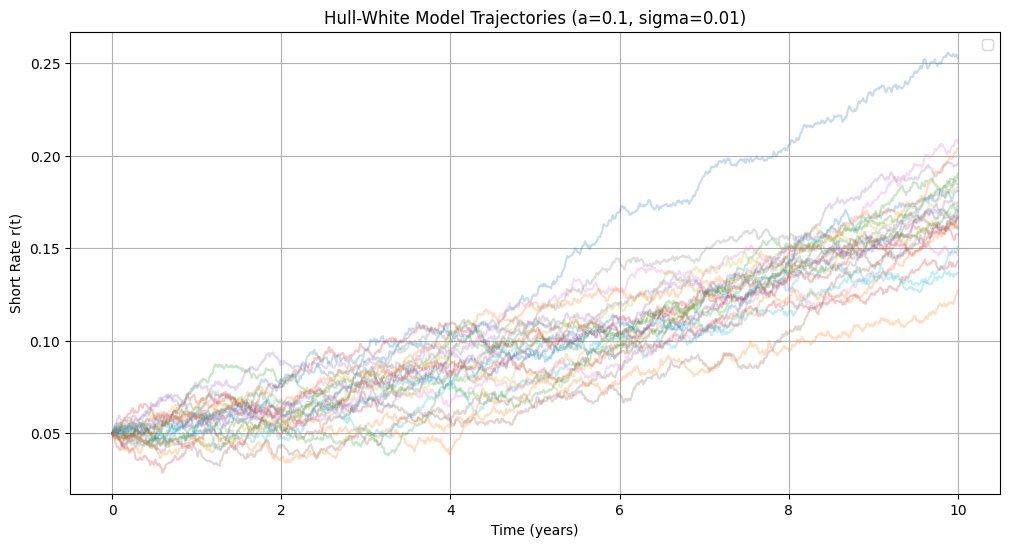

In [24]:
# Параметры модели Халла-Уайта
a = 0.1       # Скорость возврата к среднему (mean reversion speed)
sigma_hw = 0.01 # Волатильность краткосрочной ставки
r0 = 0.05     # Начальная ставка
r_long = 0.1
c_trend = 0.0025
theta_const = a * r0 # Функция theta(t). 

def theta_linear(t):
    """Линейный рост (Халл-Уайт с трендом)"""
    return a * r_long + c_trend * t

def b_hull_white(t, r):
    """
    Дрейф: theta(t) - a * r
    r имеет форму (N, 1)
    """
    return theta_linear(t) - a * r

def sigma_hull_white(t, r):
    """
    Диффузия: constant sigma
    Возвращаем форму (N, 1), чтобы совпадала с r
    """
    return np.full_like(r, sigma_hw)

np.random.seed(100500)

T = 10.0          # Горизонт моделирования (лет)
N_steps = 1000    # Количество шагов
N_sims = 25        # Количество траекторий для визуализации

ts = np.linspace(0, T, N_steps + 1)
r_init = np.array([[r0]]) # Начальное условие (1, 1)

solver = EulerSolver(b_hull_white, sigma_hull_white)

r0_batch = np.full((N_sims, 1), r0)
trajectories = solver.solve(r0_batch, ts)

plt.figure(figsize=(12, 6))
for i in range(N_sims):
    plt.plot(ts, trajectories[i, 0, :], alpha=0.25)

plt.title(f'Hull-White Model Trajectories (a={a}, sigma={sigma_hw})')
plt.xlabel('Time (years)')
plt.ylabel('Short Rate r(t)')
plt.legend()
plt.grid(True)
plt.show()

# Модель Кокса-Ингерсолла-Росса (Cox-Ingersoll-Ross, CIR)

## 1. Определение модели

Модель CIR — это однофакторная модель краткосрочной процентной ставки $r_t$, которая устраняет главный недостаток моделей Васичека и Халла-Уайта: возможность ухода ставок в отрицательную область. Она описывается следующим стохастическим дифференциальным уравнением (СДУ):

$$ dr_t = a(b - r_t)dt + \sigma \sqrt{r_t} dW_t $$

где:
*   $r_t$ — мгновенная безрисковая процентная ставка ($r_t \ge 0$).
*   $a > 0$ — скорость возврата к среднему (mean reversion speed).
*   $b > 0$ — долгосрочное среднее значение ставки (long-term mean).
*   $\sigma > 0$ — параметр волатильности.
*   $W_t$ — стандартный винеровский процесс.

**Ключевое отличие:** Волатильность пропорциональна $\sqrt{r_t}$. Это означает, что когда ставка приближается к нулю, шум затухает, что предотвращает уход $r_t$ в отрицательную область (при соблюдении определенного условия).

## 2. Ключевые свойства

1.  **Неотрицательность**: При выполнении **условия Феллера** $2ab \ge \sigma^2$ процесс никогда не достигает нуля (остается строго положительным). Если условие нарушено ($2ab < \sigma^2$), процесс может достигать нуля, но отражается от него и не уходит в минус.
2.  **Хи-квадрат распределение**: Переходное распределение $r_t$ при заданном $r_s$ является масштабированным нецентральным хи-квадрат распределением. Это позволяет выводить аналитические формулы для цен бескупонных облигаций.
3.  **Зависимость волатильности от уровня**: В отличие от моделей с постоянным $\sigma$, в CIR волатильность растет вместе со ставкой. Это лучше соответствует эмпирическим данным на многих рынках (эффект "leverage" или просто гетероскедастичность).

## 3. Численная реализация

В нотации метода Эйлера-Маруямы: 

$$ r_{t+\Delta t} = r_t + a(b - r_t)\Delta t + \sigma \sqrt{r_t} \sqrt{\Delta t} Z_t $$

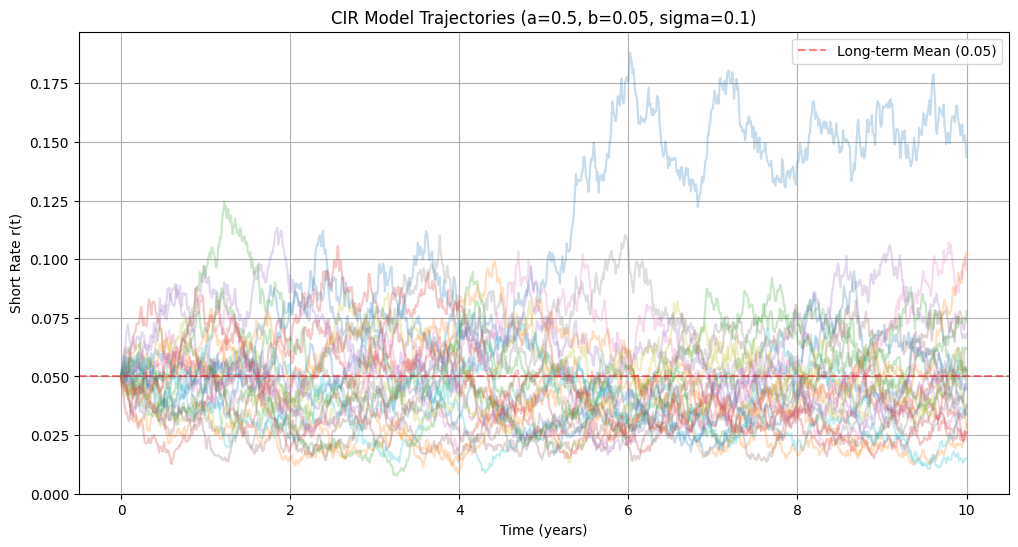

In [25]:
# --- Параметры модели CIR ---
a = 0.5       # Скорость возврата к среднему
b = 0.05      # Долгосрочное среднее (long-term mean)
sigma_cir = 0.1 # Волатильность
r0 = 0.05     # Начальная ставка

def b_cir(t, r):
    """
    Дрейф: a * (b - r)
    """
    return a * (b - r)

def sigma_cir_func(t, r):
    """
    Диффузия: sigma * sqrt(r)
    ВАЖНО: Используем max(r, 0) для защиты от NaN, если численная схема 
    случайно уведет r в небольшой минус.
    Возвращаем форму (N, 1), совместимую с r.
    """
    return sigma_cir * np.sqrt(np.maximum(r, 0))

np.random.seed(100500)

T = 10.0          # Горизонт моделирования (лет)
N_steps = 1000    # Количество шагов
N_sims = 25        # Количество траекторий для визуализации

ts = np.linspace(0, T, N_steps + 1)
r_init = np.full((N_sims, 1), r0)

solver = EulerSolver(b_cir, sigma_cir_func)
trajectories = solver.solve(r_init, ts)

plt.figure(figsize=(12, 6))
for i in range(N_sims):
    plt.plot(ts, trajectories[i, 0, :], alpha=0.25)

plt.title(f'CIR Model Trajectories (a={a}, b={b}, sigma={sigma_cir})')
plt.xlabel('Time (years)')
plt.ylabel('Short Rate r(t)')
plt.axhline(y=b, color='r', linestyle='--', alpha=0.5, label=f'Long-term Mean ({b})')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0) # Ставки не могут быть отрицательными
plt.show()

# BS через Монте-Карло

## 1. Цель 
Оценить справедливую стоимость европейского Call-опциона методом Монте-Карло в условиях, когда безрисковая процентная ставка не является константой, а следует стохастическому процессу. Сравнить полученную оценку с классической формулой Блэка-Шоулза, предполагающей постоянную ставку.

## 2. Модель
Рассматривается совместная динамика краткосрочной ставки $r_t$ и цены базового актива $S_t$ под риск-нейтральной мерой $\mathbb{Q}$.

### Система стохастических дифференциальных уравнений:
1.  **Процентная ставка (Модель Васичека):**
    $$ dr_t = \kappa(\theta - r_t)dt + \eta dW_t^r $$
    *   Ставка в среднем возвращается к уровню $\theta$ со скоростью $\kappa$.
    *   Шум $dW_t^r$ аддитивный, что допускает теоретическую возможность отрицательных ставок.

2.  **Цена актива (Обобщенное GBM):**
    $$ dS_t = r_t S_t dt + \sigma S_t dW_t^S $$
    *   Ключевое отличие от стандартного GBM: дрейф акции равен **текущей** случайной ставке $r_t$, а не константе.
    *   Шумы $W^r$ и $W^S$ независимы ($\rho=0$).

3.  **Накопленная ставка (для дисконтирования):**
    $$ dI_t = r_t dt, \quad I_0 = 0 $$
    *   Необходима для точного вычисления стохастического дисконтирующего множителя $D_T = e^{-I_T} = e^{-\int_0^T r_s ds}$.

## 3. Параметры симуляции
*   **Горизонт:** $T = 1$ год.
*   **Дискретизация:** 252 шага (дневной интервал), метод Эйлера-Маруямы.
*   **Количество траекторий:** $N = 50,000$.
*   **Параметры рынка:**
    *   $S_0 = 100, K = 100$ (At-The-Money опцион).
    *   $\sigma = 20\%$ (волатильность акции).
    *   $r_0 = \theta = 5\%$ (начальная и долгосрочная ставка).
    *   $\kappa = 0.5$ (скорость возврата ставки к среднему).
    *   $\eta = 1\%$ (волатильность ставки).

## 4. Алгоритм оценки (Monte Carlo)
1.  Генерация $N$ независимых траекторий вектора состояния $[r_t, S_t, I_t]$.
2.  Расчет выплаты по опциону в момент экспирации для каждой траектории:
    $$ \text{Payoff}_i = \max(S_T^{(i)} - K, 0) $$
3.  Дисконтирование выплат с учетом случайного пути ставки:
    $$ \text{PV}_i = \text{Payoff}_i \cdot e^{-I_T^{(i)}} $$
4.  Усреднение результатов:
    $$ V_0 \approx \frac{1}{N} \sum_{i=1}^N \text{PV}_i $$

--- Результаты ---
Цена MC (Stochastic Rate): 10.3380 +/- 0.0653
Цена BS (Constant Rate r0): 10.4506
Разница: -0.1126


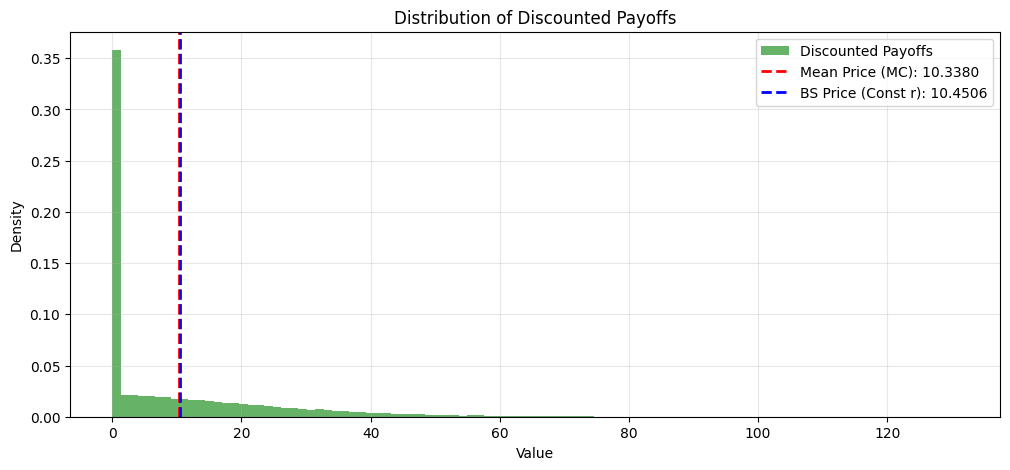

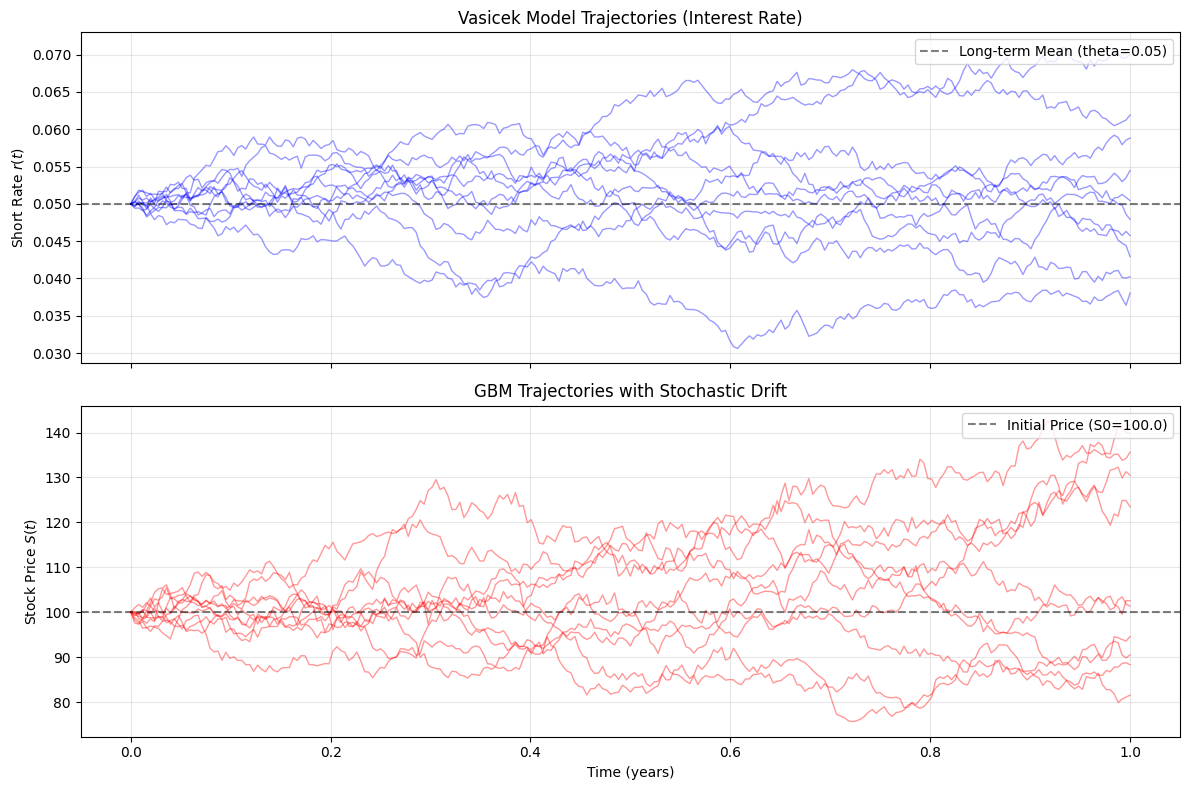

In [26]:
# ==============================================================================
# Параметры Модели
# ==============================================================================
# Модель Васичека для ставки r_t
kappa = 0.5       # Скорость возврата к среднему
theta = 0.05      # Долгосрочное среднее ставки
eta = 0.01        # Волатильность ставки

# Модель GBM для акции S_t
S0 = 100.0        # Начальная цена акции
sigma_s = 0.2     # Волатильность акции
r0 = 0.05         # Начальная ставка (совпадает с theta для стационарности)

# Опцион
K = 100.0         # Страйк
T = 1.0           # Срок жизни опциона (год)

# Параметры симуляции
N_sims = 50000    # Количество траекторий
N_steps = 252     # Шаг дискретизации (дневной)
ts = np.linspace(0, T, N_steps + 1)

np.random.seed(42)

# ==============================================================================
# Определение функций дрейфа и диффузии для системы
# ==============================================================================

def b_system(t, x):
    """
    x[:, 0] = r (ставка)
    x[:, 1] = S (акция)
    x[:, 2] = I (интеграл от ставки)
    """
    r = x[:, 0]
    S = x[:, 1]
    
    # Дрейф Васичека
    dr = kappa * (theta - r)
    # Дрейф акции (в риск-нейтральной мере дрейф равен текущей ставке r)
    dS = r * S
    # Дрейф интеграла (просто текущая ставка)
    dI = r
    
    return np.column_stack([dr, dS, dI])

def sigma_system(t, x):
    """
    Возвращаем волатильности для каждой компоненты.
    Так как шумы независимы, EulerSolver сгенерирует разные dW для каждой строки.
    """
    r = x[:, 0]
    S = x[:, 1]
    
    # Волатильность ставки (константа eta)
    sig_r = np.full_like(r, eta)
    # Волатильность акции (sigma * S)
    sig_S = sigma_s * S
    # Волатильность интеграла (0, так как dI = r*dt, шума нет)
    sig_I = np.zeros_like(r)
    
    return np.column_stack([sig_r, sig_S, sig_I])

# ==============================================================================
# Запуск симуляции 
# ==============================================================================

solver = EulerSolver(b_system, sigma_system)

# Начальное состояние: [r0, S0, I0=0]
r_init = np.full(N_sims, r0)
S_init = np.full(N_sims, S0)
I_init = np.zeros(N_sims)
x0 = np.column_stack([r_init, S_init, I_init])

# Решаем СДУ
trajectories = solver.solve(x0, ts)

# Извлекаем финальные значения
r_T = trajectories[:, 0, -1]
S_T = trajectories[:, 1, -1]
I_T = trajectories[:, 2, -1]

# Расчет цены опциона Call
payoffs = np.maximum(S_T - K, 0)
discount_factors = np.exp(-I_T)
discounted_payoffs = payoffs * discount_factors

price_mc = np.mean(discounted_payoffs)
std_error = np.std(discounted_payoffs) / np.sqrt(N_sims)

# ==============================================================================
# Аналитическая оценка (Black-Scholes с константной ставкой r0)
# ==============================================================================
def black_scholes_call(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)

# Для сравнения берем классический BS с постоянной ставкой r0
price_bs = black_scholes_call(S0, K, T, r0, sigma_s)

# ==============================================================================
# Визуализация
# ==============================================================================

print(f"--- Результаты ---")
print(f"Цена MC (Stochastic Rate): {price_mc:.4f} +/- {std_error:.4f}")
print(f"Цена BS (Constant Rate r0): {price_bs:.4f}")
print(f"Разница: {price_mc - price_bs:.4f}")

# Построение распределения дисконтированных выплат
plt.figure(figsize=(12, 5))
plt.hist(discounted_payoffs, bins=100, density=True, alpha=0.6, color='g', label='Discounted Payoffs')
plt.axvline(price_mc, color='r', linestyle='--', linewidth=2, label=f'Mean Price (MC): {price_mc:.4f}')
plt.axvline(price_bs, color='b', linestyle='--', linewidth=2, label=f'BS Price (Const r): {price_bs:.4f}')
plt.title('Distribution of Discounted Payoffs')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

fig, (ax_r, ax_s) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

time_grid = ts
n_plot = 10  # Количество траекторий для отрисовки

for i in range(n_plot):
    ax_r.plot(time_grid, trajectories[i, 0, :], 'b-', alpha=0.4, linewidth=1)
ax_r.axhline(y=theta, color='k', linestyle='--', alpha=0.5, label=f'Long-term Mean (theta={theta})')
ax_r.set_ylabel('Short Rate $r(t)$')
ax_r.set_title('Vasicek Model Trajectories (Interest Rate)')
ax_r.legend(loc='upper right')
ax_r.grid(True, alpha=0.3)

for i in range(n_plot):
    ax_s.plot(time_grid, trajectories[i, 1, :], 'r-', alpha=0.4, linewidth=1)
ax_s.axhline(y=S0, color='k', linestyle='--', alpha=0.5, label=f'Initial Price (S0={S0})')
ax_s.set_xlabel('Time (years)')
ax_s.set_ylabel('Stock Price $S(t)$')
ax_s.set_title('GBM Trajectories with Stochastic Drift')
ax_s.legend(loc='upper right')
ax_s.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()